In [1]:
import numpy as np
import torch
import torchvision

from torch import cuda
from torch.nn.functional import nll_loss, log_softmax
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from utils.progress import progressbar as pgb
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

## Exploring the data

In [3]:
fpath = "data/titanic.csv"
df = pd.read_csv(fpath)

In [4]:
df.columns.to_list()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

### Columns
source: https://www.kaggle.com/datasets/yasserh/titanic-dataset

"Pclass", "Age", "SibSp", "Parch", „Fare“, „Sex“, „Embarked“

- `PassengerId`: Passenger ID
- `Survived`*: Whether Survived or not: 0 = No, 1 = Yes
- `Pclass`*: Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd
- `Name`: Name of the Passenger
- `Sex`*: Gender
- `Age`*: Age in Years
- `SibSp`*: No. of siblings / spouses aboard the Titanic
- `Parch`*: No. of parents / children aboard the Titanic
- `Ticket`: Ticket number
- `Fare`*: Passenger fare
- `Cabin`: Cabin ID of passenger
- `Embarked`*: Port where passenger got on ship (`'S'`, `'C'`, `'Q'`, `nan`)

In [5]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

### Dropped columns

Generally discrete or (almost) unique values for each passenger.
Some may have a pattern, but would require extensive knowledge on the respective values to be interpreted.

- PassengerId: Passenger ID
- Name: Name of the Passenger
- Ticket: Ticket number
- Cabin: Cabin ID of passenger

#### PassengerId

Unique id for each passenger. No knowledge of whether consecutive numbers or patterns have any meaning.

#### Name

We have no reason to expect the name of a passenger to have any influence. Names have too many unique values.

#### Ticket

Often numbers, but also has different patterns. Therefore, not a number. Too many unique values to be interpreted as category.
Not useful unless interpreted with domain knowledge.

#### Cabin

Assigned cabin ID. Cabin IDs are not explained. Irregular pattern. Lots of `nan` (687/891)

In [6]:
df['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

In [7]:
import re

In [8]:
# lots of NaN for Cabins
df['Cabin'].isna().sum()

np.int64(687)

In [9]:
def is_unusual(row):
    v = row['Cabin']
    return not (v is np.nan or re.fullmatch('^[A-Z]\\d{1,3}', v))

# Unusual cabins
df[df.apply(is_unusual, axis=1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.00,0,0,348123,7.6500,F G73,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.00,0,1,PC 17759,63.3583,D10 D12,C
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,B58 B60,C
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C
292,293,0,2,"Levy, Mr. Rene Jacques",male,36.00,0,0,SC/Paris 2163,12.8750,D,C
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.00,0,1,PC 17558,247.5208,B58 B60,C
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S


## Tweaking parameters

### Dropout or not (and where)

~0.46+ := no dropout

**Dropout p=0.5**

Train Loss oscillates strongly

~0.454 := dropout everywhere 0.5


**Dropout p=0.2**

Train Loss oscillates less than p=0.5

~0.454 := dropout everywhere 0.2

~0.454 := dropout p=0.2 only between fc1 and fc2

Curve of "dropout everywhere" and "dropout once" pretty much the same

**Dropout once between certain layers**

Similar results whether dropping after early layer or near the end

test
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
Data types: PassengerId      int64
Survived         int64
Pclass           i

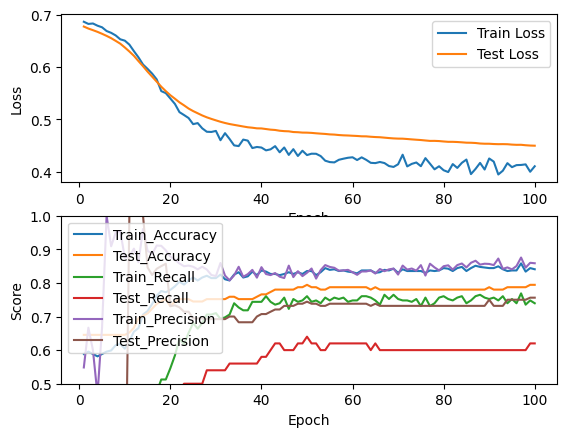

In [10]:
import titanicDataSet

titanicDataSet.main()